<a href="https://colab.research.google.com/github/ariefpurnamamuharram/ariefpurnamamuharram.github.io/blob/master/files/IF5100_Exercise_Optimization_Problems.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IF5100 - Exercise Optimization Problems
___
Name: Arief Purnama Muharram<br>
NIM: 23521013

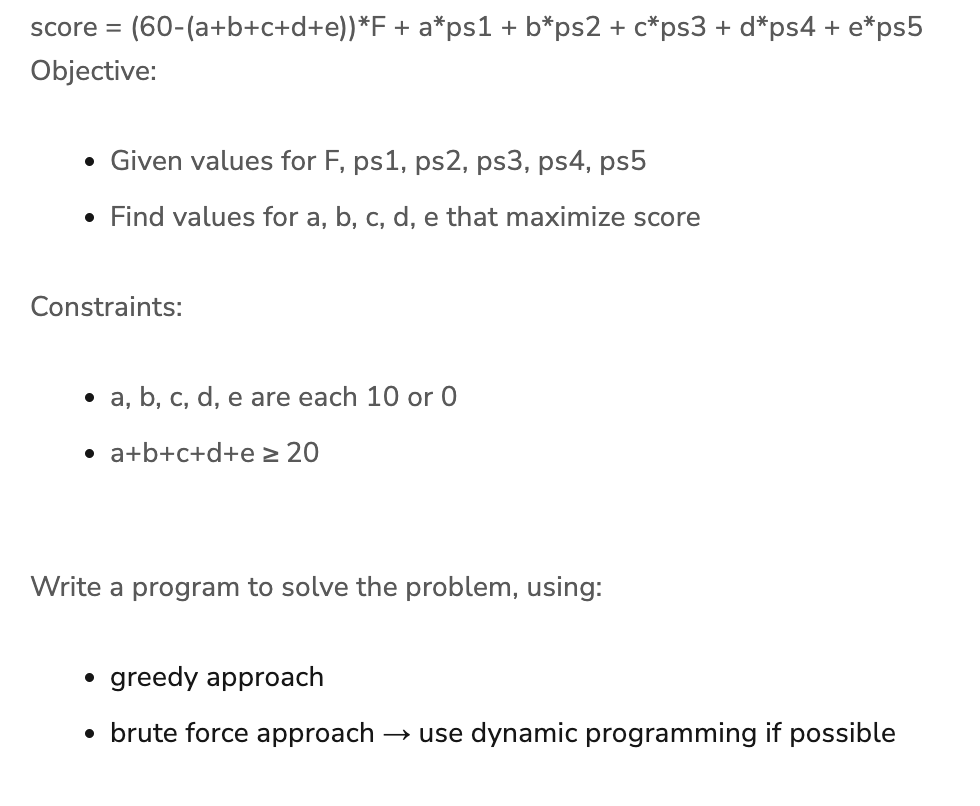

## Brute-Force Algorithm
___

In [ ]:
def calculate(f, ps1, ps2, ps3, ps4, ps5, a, b, c, d, e):
  return ((60-(a+b+c+d+e))*f)+(a*ps1)+(b*ps2)+(c*ps3)+(d*ps4)+(e*ps5)

def find_optimal_variables(f, ps1, ps2, ps3, ps4, ps5):
  prev_score = 0
  tmp_a, tmp_b, tmp_c, tmp_d, tmp_e = 0, 0, 0, 0, 0
  for a in [0, 10]:
    for b in [0, 10]:
      for c in [0, 10]:
        for d in [0, 10]:
          for e in [0, 10]:
            if a + b + c + d + e >= 20:
              score = calculate(f, ps1, ps2, ps3, ps4, ps5, a, b, c, d, e)
              if score > prev_score:
                prev_score = score
                tmp_a, tmp_b, tmp_c, tmp_d, tmp_e = a, b, c, d, e
  return tmp_a, tmp_b, tmp_c, tmp_d, tmp_e, prev_score

In [ ]:
find_optimal_variables(50, 8, 1, 1, 10, 1)

(10, 0, 0, 10, 0, 2180)

## Brute Force with Dynamic Programming Algorithm
___

In [ ]:
# Create a memo variable
memo = {}

# Create a post memo function
def post_memo(a, b):
  try:
    memo[a]
  except KeyError:
    memo[a] = {b: a * b}
  try:
    memo[a][b]
  except:
    memo[a][b] = a * b

# Score calculation function
def calculate(f, ps1, ps2, ps3, ps4, ps5, a, b, c, d, e):
  # Post memos
  post_memo(ps1, a)
  post_memo(ps2, b)
  post_memo(ps3, c)
  post_memo(ps4, d)
  post_memo(ps5, e)

  # Calculate score
  return ((60-(a+b+c+d+e))*f)+(memo[ps1][a])+(memo[ps2][b])+(memo[ps3][c])+(memo[ps4][d])+(memo[ps5][e])

def find_optimal_variables(f, ps1, ps2, ps3, ps4, ps5):
  prev_score = 0
  tmp_a, tmp_b, tmp_c, tmp_d, tmp_e = 0, 0, 0, 0, 0
  for a in [0, 10]:
    for b in [0, 10]:
      for c in [0, 10]:
        for d in [0, 10]:
          for e in [0, 10]:
            if a + b + c + d + e >= 20:
              score = calculate(f, ps1, ps2, ps3, ps4, ps5, a, b, c, d, e)
              if score > prev_score:
                prev_score = score
                tmp_a, tmp_b, tmp_c, tmp_d, tmp_e = a, b, c, d, e
  return tmp_a, tmp_b, tmp_c, tmp_d, tmp_e, prev_score

In [ ]:
find_optimal_variables(50, 8, 1, 1, 10, 1)

(10, 0, 0, 10, 0, 2180)

## Greedy Algorithm
___

In [ ]:
def calculate(f, ps1, ps2, ps3, ps4, ps5, a, b, c, d, e):
  return ((60-(a+b+c+d+e))*f)+(a*ps1)+(b*ps2)+(c*ps3)+(d*ps4)+(e*ps5)

def find_optimal_variables(f, ps1, ps2, ps3, ps4, ps5):
  prev_score = 0
  tmp_a, tmp_b, tmp_c, tmp_d, tmp_e = 0, 0, 0, 0, 0
  for a in [0, 10]:
    for b in [0, 10]:
      if a + b < 20:
        pass
      else:
        tmp_a = a
        tmp_b = b
        score = calculate(f, ps1, ps2, ps3, ps4, ps5, tmp_a, tmp_b, tmp_c, tmp_d, tmp_e)
        prev_score = score
  for c in [0, 10]:
    score = calculate(f, ps1, ps2, ps3, ps4, ps5, tmp_a, tmp_b, c, tmp_d, tmp_e)
    if score > prev_score:
      tmp_c = c
      prev_score = score
      for d in [0, 10]:
        score = calculate(f, ps1, ps2, ps3, ps4, ps5, tmp_a, tmp_b, tmp_c, d, tmp_e)
        if score > prev_score:
          tmp_d = d
          prev_score = score
          for e in [0, 10]:
            score = calculate(f, ps1, ps2, ps3, ps4, ps5, tmp_a, tmp_b, tmp_c, tmp_d, e)
            if score > prev_score:
              tmp_e = e
              return tmp_a, tmp_b, tmp_c, tmp_d, tmp_e, prev_score
            else:
              return tmp_a, tmp_b, tmp_c, tmp_d, tmp_e, prev_score
        else:
          return tmp_a, tmp_b, tmp_c, tmp_d, tmp_e, prev_score
    else:
      return tmp_a, tmp_b, tmp_c, tmp_d, tmp_e, prev_score

In [ ]:
find_optimal_variables(50, 8, 1, 1, 10, 1)

(10, 10, 0, 0, 0, 2090)